In [1]:
import ssl
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision

# This contains all the tools needed to resize, crop, rotate, flip, and alter images.
# We will use it to normalize the CIFAR-10 images and convert them to PyTorch tensors.
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Bypass SSL issue in some notebook environments
ssl._create_default_https_context = ssl._create_unverified_context

In [2]:
# Hyperparameters
batch_size = 128
learning_rate = 0.001
weight_decay = 1e-4
epochs = 20
validation_size = 5000
CHECK_POINT_PATH = "best_fairface_model.pt"

FairFace is a face image dataset which is race balanced. It contains 108,501 images from 7 different race groups: White, Black, Indian, East Asian, Southeast Asian, Middle Eastern, and Latino. Images were collected from the YFCC-100M Flickr dataset and labeled with race, gender, and age groups.

In [3]:
# ----------------------------
# Load dataset
# ----------------------------

torch.cuda.empty_cache()
from datasets import load_dataset
dataset = load_dataset(
    "HuggingFaceM4/FairFace",
    "0.25",
    cache_dir=".\dataset"
)

train_ds = dataset["train"]
test_ds = dataset["validation"]

ages = set(sample["age"] for sample in train_ds)

In [4]:
import os
from PIL import Image
import pandas as pd
from datasets import load_dataset

save_dir = "fairface_sample"
img_dir = os.path.join(save_dir, "images")
csv_path = os.path.join(save_dir, "labels.csv")

# ----------------------------
# SKIP IF ALREADY EXISTS
# ----------------------------
if os.path.exists(csv_path):
    print("Dataset already exists. Skipping download.")
else:
    os.makedirs(img_dir, exist_ok=True)

    dataset = load_dataset("HuggingFaceM4/FairFace", "0.25")
    samples = dataset["train"].select(range(10))

    data = []

    for i, sample in enumerate(samples):

        img = sample["image"]
        age = sample["age"]
        race = sample["race"]
        gender = sample["gender"]

        img_path = os.path.join(img_dir, f"img_{i}.jpg")
        img.save(img_path)

        data.append({
            "image": f"img_{i}.jpg",
            "age": age,
            "race": race,
            "gender": gender
        })

    df = pd.DataFrame(data)
    df.to_csv(csv_path, index=False)

    print("Dataset sample created successfully.")

Dataset already exists. Skipping download.


Data Fields
- image: The image
- age: Age class among ["0-2", "3-9", "10-19", "20-29", "30-39", "40-49", "50-59", "60-69", "more than 70"]
- gender: Gender class among ["Male", "Female"]
- race: Race class among ["East Asian", "Indian", "Black", "White", "Middle Eastern", "Latino_Hispanic", "Southeast Asian"]

In [5]:
print(
    open("MLModel.py", "r").read()
)

from torchvision import transforms

# CIFAR-10 normalization values
mean = (0.4914, 0.4822, 0.4465)             # RGB
std = (0.2470, 0.2435, 0.2616)

num_classes = 9

train_transform = transforms.Compose([
    transforms.RandomCrop(32,padding=4),    # add 4 pixel padding arround the picture and randomly crop for 32 pixel picture
                                            # this is done to randomly place the image at a random place to help prediction accurate
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),                  # values map to 0,1 from 0,256 to make train more stable
    transforms.Normalize(mean,std)
])

# validation/ test
eval_transform = transforms.Compose([
    transforms.Resize((32,32)),
    transforms.ToTensor(),                  
    transforms.Normalize(mean,std)
])

import torch.nn as nn

# CNN model
class CNN(nn.Module):

    def __init__(self, num_classes):
        super().__init__()

        # feature extractor using the original simple pattern

In [6]:
from MLModel import CNN, train_transform, eval_transform

def train_transform_fn(example):
    if isinstance(example["image"], list):
        example["image"] = [train_transform(img) for img in example["image"]]
    else:
        example["image"] = train_transform(example["image"])
    return example


def eval_transform_fn(example):
    if isinstance(example["image"], list):
        example["image"] = [eval_transform(img) for img in example["image"]]
    else:
        example["image"] = eval_transform(example["image"])
    return example

In [7]:
# ----------------------------
# Custom Dataset Wrapper
# ----------------------------
# 6. Train / validation set
indices = torch.randperm(
    len(train_ds),
    generator=torch.Generator().manual_seed(42)
).tolist()

val_indices = indices[:validation_size]
train_indices = indices[validation_size:]

train_dataset = train_ds.select(train_indices)
train_dataset.set_transform(train_transform_fn)

val_dataset = train_ds.select(val_indices)
val_dataset.set_transform(eval_transform_fn)

test_dataset = test_ds
test_dataset.set_transform(eval_transform_fn)

train_dataset = DataLoader(train_dataset,batch_size=batch_size,shuffle=True)
val_dataset = DataLoader(val_dataset,batch_size=batch_size,shuffle=False)
test_dataset = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [8]:
num_classes = len(ages)
print("number of data classes in the dataset = ",num_classes)


model = CNN(len(ages)).to(device)

number of data classes in the dataset =  9


In [9]:
# List for monitoring
train_validation_losses = {
    "train_loss" : [],
    "validation_loss" : []
}
train_validation_accuracies = {
    "train_accuracies" : [],
    "validation_accuracies" : []
}
best_value_accuracy = 0.0

In [10]:
criterion = nn.CrossEntropyLoss()
optimiser = optim.AdamW(model.parameters(),lr=learning_rate,weight_decay=weight_decay)

In [11]:
def evaluate(model, data_loader):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for batch in data_loader:
            images = batch["image"]
            labels = batch["age"]

            if not isinstance(labels, torch.Tensor):
                labels = torch.tensor(labels)

            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)
            total += labels.size(0)
            correct += (predictions == labels).sum().item()

    epoch_loss = running_loss / len(data_loader.dataset)
    epoch_accuracy = 100 * correct / total
    return epoch_loss, epoch_accuracy

In [12]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

In [13]:
def safe_batch(batch):
    images = batch["image"]
    labels = batch["age"]

    # Convert safely
    if not isinstance(images, torch.Tensor):
        images = torch.stack(images)

    if not isinstance(labels, torch.Tensor):
        labels = torch.tensor(labels)

    # Move to device
    images = images.to(device, dtype=torch.float32)
    labels = labels.to(device).long()

    # HARD CHECK (prevents CUDA poisoning)
    if labels.min() < 0 or labels.max() >= len(ages):
        raise ValueError(f"Invalid labels detected: {labels.min()} - {labels.max()}")

    return images, labels

In [14]:
for epoch in range(epochs):
    model.train()

    running_training_loss = 0.0
    train_correct = 0
    train_total = 0

    for batch in train_dataset:

        try:
            # =========================
            # SAFE BATCH PROCESSING
            # =========================
            images, labels = safe_batch(batch)

            # =========================
            # FORWARD PASS
            # =========================
            optimiser.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            # =========================
            # BACKWARD PASS
            # =========================
            loss.backward()
            optimiser.step()

            # =========================
            # METRICS
            # =========================
            running_training_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)

            train_total += labels.size(0)
            train_correct += (predictions == labels).sum().item()

        except Exception as e:
            print("⚠️ Skipping bad batch:", e)
            continue

    # =========================
    # EPOCH METRICS
    # =========================
    epoch_train_loss = running_training_loss / len(train_dataset.dataset)
    epoch_train_accuracy = 100 * train_correct / train_total

    epoch_val_loss, epoch_val_accuracy = evaluate(model, val_dataset)

    train_validation_losses["train_loss"].append(epoch_train_loss)
    train_validation_accuracies["train_accuracies"].append(epoch_train_accuracy)
    train_validation_losses["validation_loss"].append(epoch_val_loss)
    train_validation_accuracies["validation_accuracies"].append(epoch_val_accuracy)

    print(
        f"Epoch [{epoch+1}/{epochs}] | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Train Accuracy: {epoch_train_accuracy:.2f}% | "
        f"Val Loss: {epoch_val_loss:.4f} | "
        f"Val Accuracy: {epoch_val_accuracy:.2f}%"
    )

    # =========================
    # CHECKPOINTING
    # =========================
    if epoch_val_accuracy > best_value_accuracy:
        best_value_accuracy = epoch_val_accuracy

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimiser.state_dict(),
                "val_accuracy": epoch_val_accuracy,
                "val_loss": epoch_val_loss,
            },
            CHECK_POINT_PATH,
        )

        print(f"🏆 Best model saved at epoch {epoch+1}\n")

Epoch [1/20] | Train Loss: 1.8724 | Train Accuracy: 29.28% | Val Loss: 1.8671 | Val Accuracy: 30.00%
🏆 Best model saved at epoch 1

Epoch [2/20] | Train Loss: 1.8677 | Train Accuracy: 29.47% | Val Loss: 1.8694 | Val Accuracy: 30.00%
Epoch [3/20] | Train Loss: 1.8665 | Train Accuracy: 29.48% | Val Loss: 1.8576 | Val Accuracy: 30.00%
Epoch [4/20] | Train Loss: 1.8662 | Train Accuracy: 29.48% | Val Loss: 1.8553 | Val Accuracy: 30.00%
Epoch [5/20] | Train Loss: 1.8652 | Train Accuracy: 29.48% | Val Loss: 1.8516 | Val Accuracy: 30.00%
Epoch [6/20] | Train Loss: 1.8649 | Train Accuracy: 29.48% | Val Loss: 1.8547 | Val Accuracy: 30.00%
Epoch [7/20] | Train Loss: 1.8640 | Train Accuracy: 29.48% | Val Loss: 1.8543 | Val Accuracy: 30.00%
Epoch [8/20] | Train Loss: 1.8637 | Train Accuracy: 29.48% | Val Loss: 1.8566 | Val Accuracy: 30.00%
Epoch [9/20] | Train Loss: 1.8633 | Train Accuracy: 29.48% | Val Loss: 1.8524 | Val Accuracy: 30.00%
Epoch [10/20] | Train Loss: 1.8615 | Train Accuracy: 29.48% 

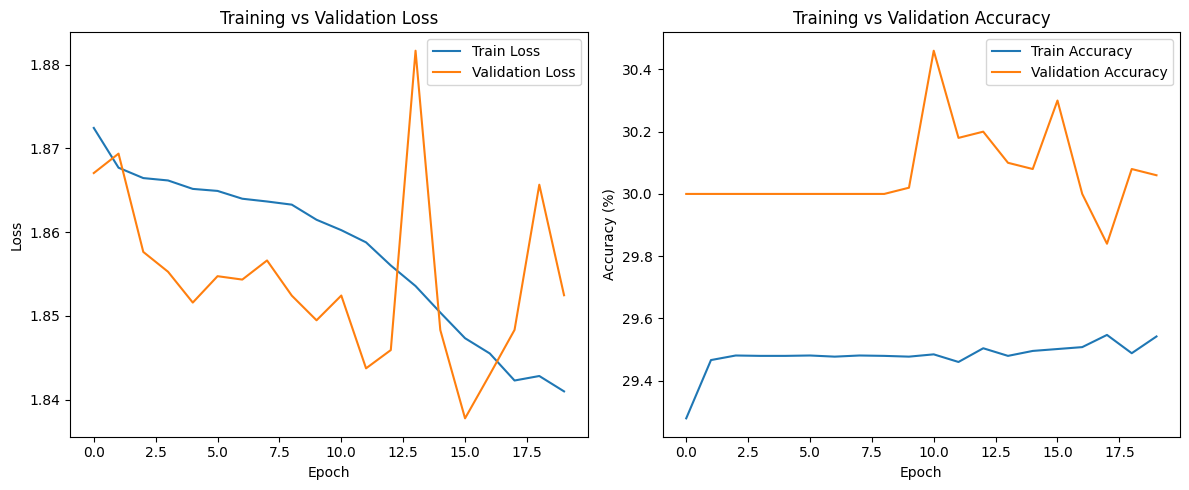

In [15]:
# 12. Plot graphs
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_validation_losses["train_loss"], label="Train Loss")
plt.plot(train_validation_losses["validation_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_validation_accuracies["train_accuracies"], label="Train Accuracy")
plt.plot(train_validation_accuracies["validation_accuracies"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [16]:
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score
import numpy as np

In [17]:
def full_evaluate(model, data_loader):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in data_loader:

            images = batch["image"].to(device)
            labels = batch["age"].to(device)

            outputs = model(images)
            preds = outputs.argmax(dim=1)

            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    # flatten
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    # metrics
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="weighted")
    cm = confusion_matrix(all_labels, all_preds)

    report = classification_report(all_labels, all_preds)

    return acc, f1, cm, report

In [18]:
model = CNN(num_classes).to(device)
checkpoint = torch.load(
    CHECK_POINT_PATH,
    map_location=device
)
model.load_state_dict(checkpoint["model_state_dict"])

<All keys matched successfully>

In [19]:
acc, f1, cm, report = full_evaluate(model, val_dataset)

print("Accuracy:", acc)
print("F1 Score:", f1)
print("\nClassification Report:\n", report)

Accuracy: 0.3046
F1 Score: 0.15339842490051858

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       109
           1       0.41      0.07      0.13       574
           2       0.00      0.00      0.00       515
           3       0.30      0.99      0.46      1500
           4       0.00      0.00      0.00      1105
           5       0.00      0.00      0.00       617
           6       0.00      0.00      0.00       376
           7       0.00      0.00      0.00       155
           8       0.00      0.00      0.00        49

    accuracy                           0.30      5000
   macro avg       0.08      0.12      0.07      5000
weighted avg       0.14      0.30      0.15      5000



d:\IJSE CAME\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\IJSE CAME\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\IJSE CAME\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


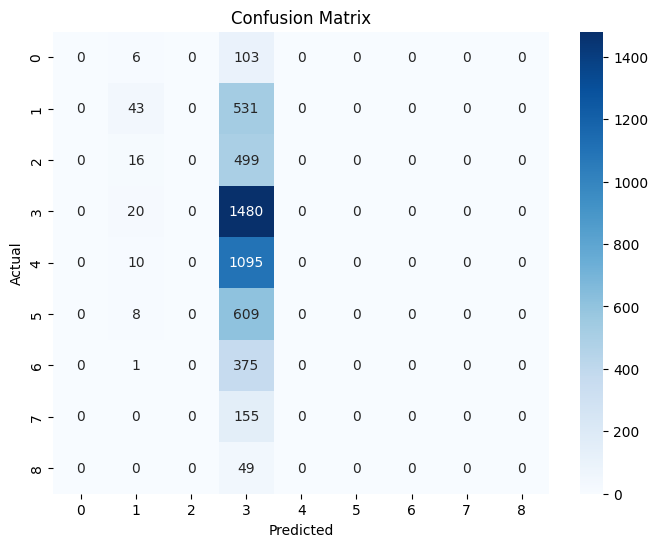

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()